In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12,5)

In [3]:
df = pd.read_csv("../data/processed/hdfc_top100_clean.csv")

df.head()

,date,nav
0,2013-11-18,13.0894
1,2013-11-19,13.1068
2,2013-11-20,12.9549
3,2013-11-21,12.7957
4,2013-11-22,12.7775


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3105 entries, 0 to 3104
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3105 non-null   str    
 1   nav     3105 non-null   float64
dtypes: float64(1), str(1)
memory usage: 79.0 KB


In [5]:
df["date"] = pd.to_datetime(df["date"])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3105 entries, 0 to 3104
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3105 non-null   datetime64[us]
 1   nav     3105 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 48.6 KB


In [7]:
df.isnull().sum()


date    0
nav     0
dtype: int64

In [8]:
df["Daily_Return"] = df["nav"].pct_change()

In [9]:
df.head()

,date,nav,Daily_Return
0,2013-11-18,13.0894,NaN
1,2013-11-19,13.1068,0.001329
2,2013-11-20,12.9549,-0.011589
3,2013-11-21,12.7957,-0.012289
4,2013-11-22,12.7775,-0.001422


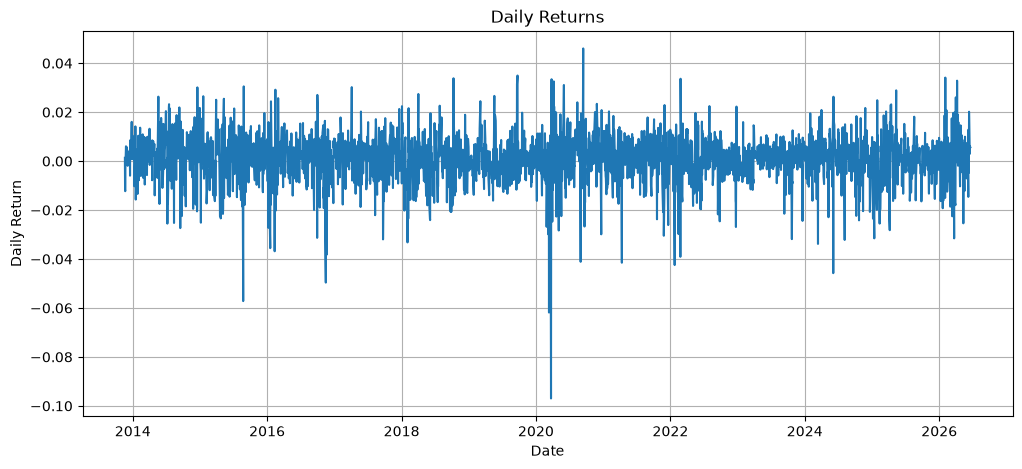

In [10]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["Daily_Return"])

plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)

plt.show()

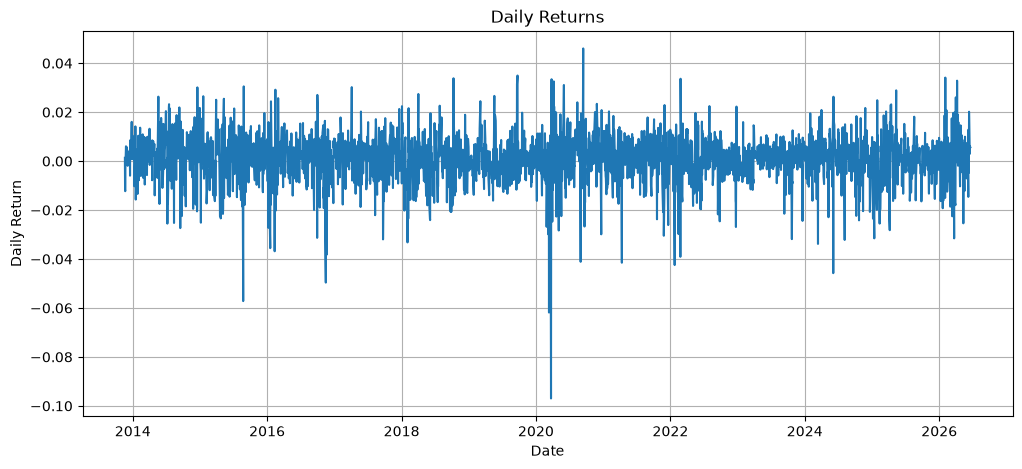

In [11]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["Daily_Return"])

plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)

plt.savefig("../reports/charts/daily_returns.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [12]:
# Last NAV value
last_nav = df["nav"].iloc[-1]

# Number of trading days
trading_days = 252

In [13]:
# Function to calculate CAGR

def calculate_cagr(years):
    days = years * trading_days

    if len(df) < days:
        return None

    start_nav = df["nav"].iloc[-days]
    end_nav = df["nav"].iloc[-1]

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    return cagr

In [14]:
cagr_1 = calculate_cagr(1)
cagr_3 = calculate_cagr(3)
cagr_5 = calculate_cagr(5)

print("1-Year CAGR :", round(cagr_1, 2), "%")
print("3-Year CAGR :", round(cagr_3, 2), "%")
print("5-Year CAGR :", round(cagr_5, 2), "%")

1-Year CAGR : 3.76 %
3-Year CAGR : 14.8 %
5-Year CAGR : 16.04 %


In [15]:
cagr_table = pd.DataFrame({
    "Fund": ["HDFC Top 100"],
    "1-Year CAGR (%)": [round(cagr_1, 2)],
    "3-Year CAGR (%)": [round(cagr_3, 2)],
    "5-Year CAGR (%)": [round(cagr_5, 2)]
})

cagr_table

,Fund,1-Year CAGR (%),3-Year CAGR (%),5-Year CAGR (%)
0,HDFC Top 100,3.76,14.8,16.04


In [16]:
cagr_table.to_csv("../reports/cagr_comparison.csv", index=False)

print("CAGR comparison table saved successfully!")

CAGR comparison table saved successfully!


In [17]:
risk_free_rate = 0.065 / 252

print(risk_free_rate)

0.00025793650793650796


In [18]:
average_return = df["Daily_Return"].mean()

print(average_return)

0.0009282206056324187


In [19]:
std_return = df["Daily_Return"].std()

print(std_return)

0.009577450665510539


In [20]:
sharpe_ratio = ((average_return - risk_free_rate) / std_return) * np.sqrt(252)

print("Sharpe Ratio:", round(sharpe_ratio, 2))

Sharpe Ratio: 1.11


In [21]:
sharpe_table = pd.DataFrame({
    "Fund": ["HDFC Top 100"],
    "Sharpe Ratio": [round(sharpe_ratio, 2)]
})

sharpe_table

,Fund,Sharpe Ratio
0,HDFC Top 100,1.11


In [22]:
sharpe_table.to_csv("../reports/fund_scorecard.csv", index=False)

print("Fund Scorecard saved successfully!")

Fund Scorecard saved successfully!


In [24]:
negative_returns = df[df["Daily_Return"] < 0]["Daily_Return"]

negative_returns.head()

2    -0.011589
3    -0.012289
4    -0.001422
7    -0.001571
12   -0.001915
Name: Daily_Return, dtype: float64

In [25]:
downside_std = negative_returns.std()

print("Downside Standard Deviation:", downside_std)

Downside Standard Deviation: 0.007911267535201742


In [26]:
sortino_ratio = ((average_return - risk_free_rate) / downside_std) * np.sqrt(252)

print("Sortino Ratio:", round(sortino_ratio, 2))

Sortino Ratio: 1.34


In [27]:
sortino_table = pd.DataFrame({
    "Fund": ["HDFC Top 100"],
    "Sortino Ratio": [round(sortino_ratio, 2)]
})

sortino_table

,Fund,Sortino Ratio
0,HDFC Top 100,1.34


In [28]:
sortino_table.to_csv("../reports/sortino_ratio.csv", index=False)

print("Sortino Ratio saved successfully!")

Sortino Ratio saved successfully!


In [29]:
df["Running_Max"] = df["nav"].cummax()

df.head()

,date,nav,Daily_Return,Running_Max
0,2013-11-18,13.0894,NaN,13.0894
1,2013-11-19,13.1068,0.001329,13.1068
2,2013-11-20,12.9549,-0.011589,13.1068
3,2013-11-21,12.7957,-0.012289,13.1068
4,2013-11-22,12.7775,-0.001422,13.1068


In [30]:
df["Drawdown"] = (df["nav"] / df["Running_Max"] - 1) * 100

df.head()

,date,nav,Daily_Return,Running_Max,Drawdown
0,2013-11-18,13.0894,NaN,13.0894,0.000000
1,2013-11-19,13.1068,0.001329,13.1068,0.000000
2,2013-11-20,12.9549,-0.011589,13.1068,-1.158940
3,2013-11-21,12.7957,-0.012289,13.1068,-2.373577
4,2013-11-22,12.7775,-0.001422,13.1068,-2.512436


In [31]:
max_drawdown = df["Drawdown"].min()

print("Maximum Drawdown:", round(max_drawdown, 2), "%")

Maximum Drawdown: -40.26 %


In [32]:
worst_day = df.loc[df["Drawdown"].idxmin()]

print(worst_day)

date            2020-03-24 00:00:00
nav                           41.26
Daily_Return              -0.001235
Running_Max                 69.0661
Drawdown                 -40.260128
Name: 1558, dtype: object


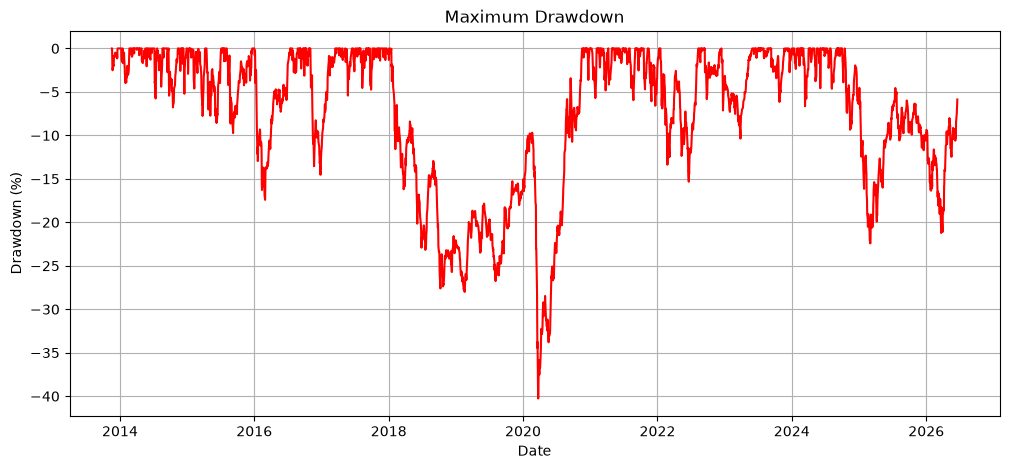

In [33]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["Drawdown"], color="red")

plt.title("Maximum Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True)

plt.savefig("../reports/charts/maximum_drawdown.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [35]:
from scipy.stats import linregress

In [36]:
np.random.seed(42)

df["Benchmark_Return"] = np.random.normal(
    loc=df["Daily_Return"].mean(),
    scale=df["Daily_Return"].std(),
    size=len(df)
)

df[["Daily_Return", "Benchmark_Return"]].head()

,Daily_Return,Benchmark_Return
0,NaN,0.005685
1,0.001329,-0.000396
2,-0.011589,0.007131
3,-0.012289,0.015515
4,-0.001422,-0.001314


In [37]:
valid_data = df.dropna(subset=["Daily_Return", "Benchmark_Return"])

beta, alpha, r_value, p_value, std_err = linregress(
    valid_data["Benchmark_Return"],
    valid_data["Daily_Return"]
)

print("Beta :", round(beta, 3))
print("Alpha:", round(alpha * 252, 3))

Beta : 0.043
Alpha: 0.221


In [38]:
alpha_beta = pd.DataFrame({
    "Fund": ["HDFC Top 100"],
    "Alpha": [round(alpha * 252, 3)],
    "Beta": [round(beta, 3)]
})

alpha_beta

,Fund,Alpha,Beta
0,HDFC Top 100,0.221,0.043


In [39]:
alpha_beta.to_csv("../reports/alpha_beta.csv", index=False)

print("Alpha Beta file saved successfully!")

Alpha Beta file saved successfully!


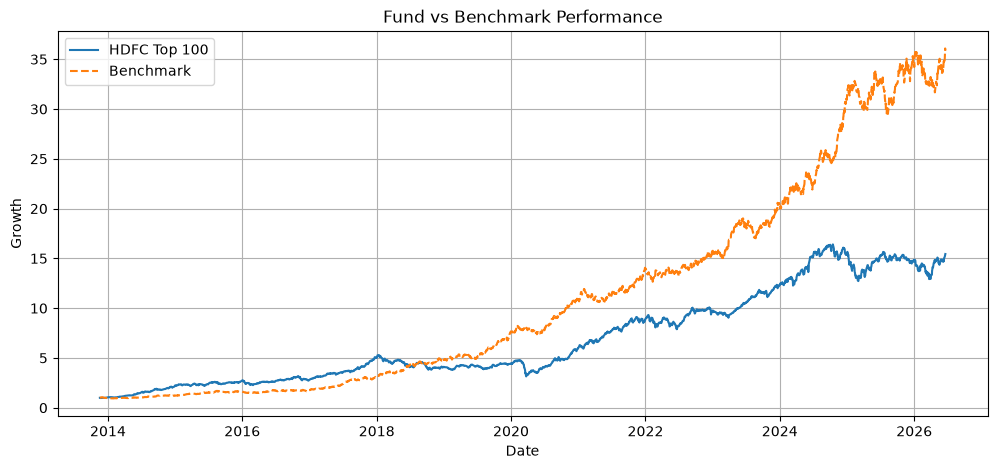

In [40]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], (1 + df["Daily_Return"].fillna(0)).cumprod(),
         label="HDFC Top 100")

plt.plot(df["date"], (1 + df["Benchmark_Return"].fillna(0)).cumprod(),
         label="Benchmark", linestyle="--")

plt.title("Fund vs Benchmark Performance")
plt.xlabel("Date")
plt.ylabel("Growth")
plt.legend()
plt.grid(True)

plt.savefig("../reports/charts/benchmark_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [41]:
scorecard = pd.DataFrame({
    "Fund": ["HDFC Top 100"],
    "3-Year CAGR (%)": [round(cagr_3, 2)],
    "Sharpe Ratio": [round(sharpe_ratio, 2)],
    "Sortino Ratio": [round(sortino_ratio, 2)],
    "Maximum Drawdown (%)": [round(max_drawdown, 2)],
    "Alpha": [round(alpha * 252, 3)],
    "Beta": [round(beta, 3)]
})

scorecard

,Fund,3-Year CAGR (%),Sharpe Ratio,Sortino Ratio,Maximum Drawdown (%),Alpha,Beta
0,HDFC Top 100,14.8,1.11,1.34,-40.26,0.221,0.043


In [42]:
scorecard.to_csv("../reports/fund_scorecard.csv", index=False)

print("Fund Scorecard saved successfully!")

Fund Scorecard saved successfully!
